# Fleet Model Runner

Run the fleet model from the config file and load the saved result tables.

In [6]:
from pathlib import Path
import subprocess
import sys

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

command = [sys.executable, str(script_path), "--config", str(config_path)]
print(" ".join(command))
subprocess.run(command, check=True)

c:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\.venv\Scripts\python.exe C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_with_policies.py --config C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_config.json


CompletedProcess(args=['c:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\.venv\\Scripts\\python.exe', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_with_policies.py', '--config', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_config.json'], returncode=0)

In [7]:
import pandas as pd

results_dir = model_dir / "Results"

result_files = {
    path.stem: path
    for path in results_dir.glob("*.csv")
}

results = {
    name: pd.read_csv(path, sep=";")
    for name, path in result_files.items()
}

results.keys()

dict_keys(['fleet_size_final_stock_all', 'fleet_size_new_vehicles_all', 'fleet_size_summary_all', 'fleet_size_target_paths_all', 'fleet_total', 'hazard_pooled', 'policy_exits_all', 'policy_final_stock_all', 'policy_missing_vehicles_all', 'policy_new_vehicles_all', 'policy_reentries_all', 'policy_stock_before_new_vehicles_all', 'policy_summary_all', 'reentry_pooled', 'reentry_yearly'])

In [8]:
# Main result dataframes for evaluation
policy_summary_all = results["policy_summary_all"]
policy_final_stock_all = results["policy_final_stock_all"]
policy_exits_all = results["policy_exits_all"]
policy_reentries_all = results["policy_reentries_all"]
policy_new_vehicles_all = results["policy_new_vehicles_all"]

policy_summary_all.head()

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,baseline,2025,4.948649e+07,4.948647e+07,1.600000e+01,4.948647e+07,-1.600000e+01
1,baseline,2026,4.976391e+07,4.635019e+07,3.413728e+06,4.976391e+07,0.000000e+00
2,baseline,2027,5.004290e+07,4.652828e+07,3.514620e+06,5.004290e+07,0.000000e+00
3,baseline,2028,5.032345e+07,4.671656e+07,3.606882e+06,5.032345e+07,-7.450581e-09
4,baseline,2029,5.060557e+07,4.691737e+07,3.688192e+06,5.060557e+07,0.000000e+00


In [9]:
policy_summary_all

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,baseline,2025,4.948649e+07,4.948647e+07,1.600000e+01,4.948647e+07,-1.600000e+01
1,baseline,2026,4.976391e+07,4.635019e+07,3.413728e+06,4.976391e+07,0.000000e+00
2,baseline,2027,5.004290e+07,4.652828e+07,3.514620e+06,5.004290e+07,0.000000e+00
3,baseline,2028,5.032345e+07,4.671656e+07,3.606882e+06,5.032345e+07,-7.450581e-09
4,baseline,2029,5.060557e+07,4.691737e+07,3.688192e+06,5.060557e+07,0.000000e+00
...,...,...,...,...,...,...,...
99,abwrackpraemie,2046,5.565098e+07,5.062797e+07,5.023007e+06,5.565098e+07,7.450581e-09
100,abwrackpraemie,2047,5.596297e+07,5.087323e+07,5.089733e+06,5.596297e+07,0.000000e+00
101,abwrackpraemie,2048,5.627670e+07,5.113192e+07,5.144779e+06,5.627670e+07,7.450581e-09
102,abwrackpraemie,2049,5.659220e+07,5.141832e+07,5.173878e+06,5.659220e+07,7.450581e-09


# Plot

Gefundene Szenarien:
['abwrackpraemie', 'baseline', 'diesel_fahrverbot', 'verbrenneraus']

Gefundene Antriebsarten:
['Benzin', 'Diesel', 'Elektro (BEV)', 'Erdgas (CNG) (einschl. bivalent)', 'Flüssiggas (LPG) (einschl. bivalent)', 'Hybrid', 'Sonstige']


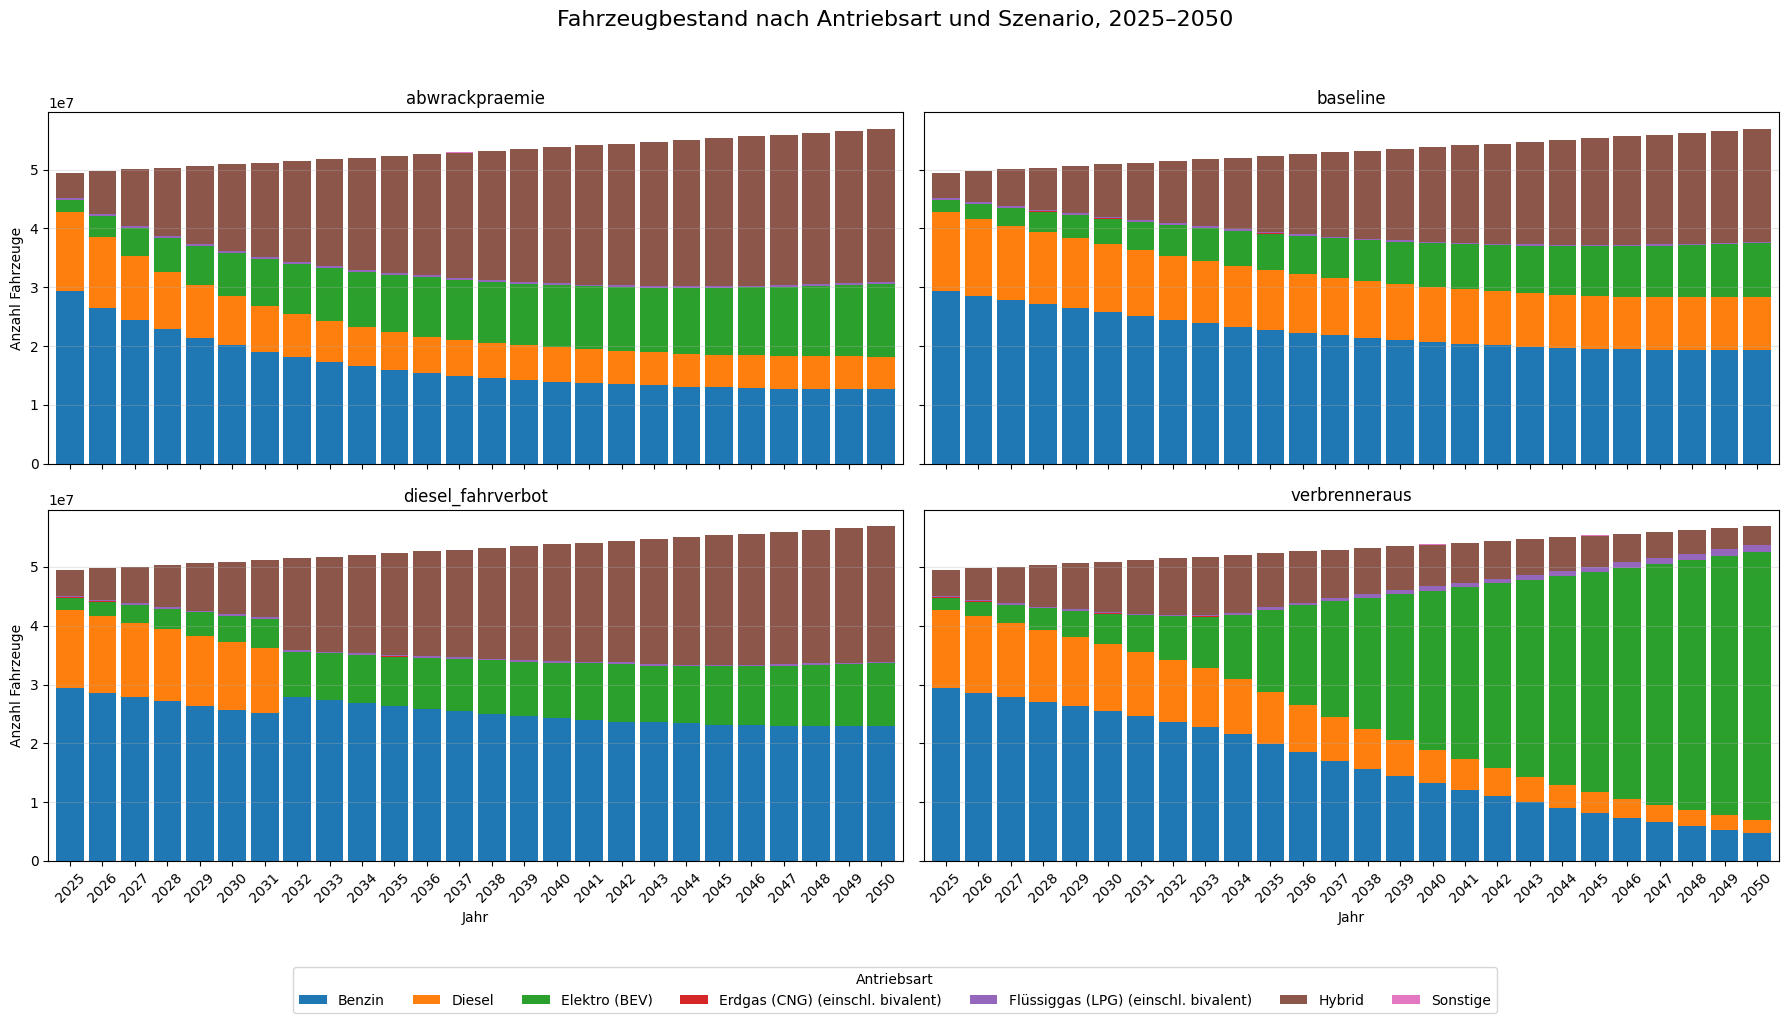

Grafik gespeichert unter:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. Datei einlesen
# ------------------------------------------------------------

file_path = Path(
    r"C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\policy_final_stock_all.csv"
)

df = pd.read_csv(file_path, sep=";")

# ------------------------------------------------------------
# 2. Datentypen bereinigen
# ------------------------------------------------------------

df["Jahr"] = df["Jahr"].astype(int)
df["finaler_bestand"] = pd.to_numeric(df["finaler_bestand"], errors="coerce")

# ------------------------------------------------------------
# 3. Nur Jahre 2025 bis 2050 verwenden
# ------------------------------------------------------------

df = df[(df["Jahr"] >= 2025) & (df["Jahr"] <= 2050)]

# ------------------------------------------------------------
# 4. Fahrzeugbestand pro Szenario, Jahr und Antriebsart summieren
# ------------------------------------------------------------

agg = (
    df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)["finaler_bestand"]
    .sum()
)

# ------------------------------------------------------------
# 5. Szenarien und Antriebsarten bestimmen
# ------------------------------------------------------------

szenarien = sorted(agg["Szenario"].unique())
antriebsarten = sorted(agg["Antriebsart"].unique())

print("Gefundene Szenarien:")
print(szenarien)

print("\nGefundene Antriebsarten:")
print(antriebsarten)

# ------------------------------------------------------------
# 6. 2x2 Plot mit gestapelten Balkendiagrammen erstellen
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, szenario in zip(axes, szenarien):
    
    data_szenario = agg[agg["Szenario"] == szenario]

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Antriebsarten
    # Werte = Fahrzeugbestand
    pivot = (
        data_szenario
        .pivot_table(
            index="Jahr",
            columns="Antriebsart",
            values="finaler_bestand",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(range(2025, 2051), fill_value=0)
    )

    # Sicherstellen, dass in jedem Subplot alle Antriebsarten vorkommen
    pivot = pivot.reindex(columns=antriebsarten, fill_value=0)

    # Gestapeltes Balkendiagramm
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(szenario)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Anzahl Fahrzeuge")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    # Einzelne Legende entfernen, da später gemeinsame Legende kommt
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Falls weniger als 4 Szenarien vorhanden sind, leere Subplots ausblenden
for i in range(len(szenarien), len(axes)):
    axes[i].set_visible(False)

# ------------------------------------------------------------
# 7. Gemeinsame Legende erstellen
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Antriebsart",
    loc="lower center",
    ncol=len(antriebsarten),
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Fahrzeugbestand nach Antriebsart und Szenario, 2025–2050",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# ------------------------------------------------------------
# 8. Grafik speichern
# ------------------------------------------------------------

output_path = file_path.parent / "policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Grafik gespeichert unter:\n{output_path}")